In [1]:
# ============================================
# MODULE 2 — ANALYTICS
# Step 1: Import Required Libraries
# ============================================

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# ============================================
# Step 2: Load Titanic Dataset
# ============================================

df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully.")
print("Dataset shape:", df.shape)

Titanic dataset loaded successfully.
Dataset shape: (891, 15)


In [3]:
# ============================================
# Step 3: Save Offline Dataset
# ============================================

csv_path = Path("titanic.csv")

df.to_csv(csv_path, index=False)

print("Titanic dataset saved successfully.")
print("File:", csv_path.resolve())

Titanic dataset saved successfully.
File: C:\zepto-data-ai-platform\analytics\titanic.csv


In [4]:
# ============================================
# Step 4: Dataset Shape
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape:
(891, 15)

Number of Rows: 891
Number of Columns: 15


In [5]:
# ============================================
# Step 5: Dataset Information
# ============================================

print("Dataset Information:")
print("=" * 60)

df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
# ============================================
# Step 6: Descriptive Statistics
# ============================================

print("Descriptive Statistics:")
print("=" * 60)

display(df.describe(include="all").T)

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ============================================
# Step 7: Missing Value Analysis
# ============================================

missing_count = df.isna().sum()
missing_percentage = (df.isna().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_report = missing_report[
    missing_report["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

print("Missing Value Report:")
print("=" * 60)

display(missing_report)

Missing Value Report:


,Missing Count,Missing Percentage
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [8]:
# ============================================
# Step 8: Missing-Value Cleaning
# ============================================

clean_df = df.copy()

# --------------------------------------------
# 1. Age: 19.87% missing
# Rule: 5%–30% -> Impute
# --------------------------------------------

age_median = clean_df["age"].median()

clean_df["age"] = clean_df["age"].fillna(age_median)

print(f"Age median used for imputation: {age_median:.2f}")


# --------------------------------------------
# 2. Embarked: 0.22% missing
# Rule: <5% -> Drop affected rows
# --------------------------------------------

clean_df = clean_df.dropna(subset=["embarked"])


# --------------------------------------------
# 3. embark_town: redundant with embarked
# --------------------------------------------

clean_df = clean_df.drop(columns=["embark_town"])


# --------------------------------------------
# 4. Deck: 77.22% missing
# Very high missingness -> Drop column
# --------------------------------------------

clean_df = clean_df.drop(columns=["deck"])


print("\nCleaning completed.")
print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

Age median used for imputation: 28.00

Cleaning completed.
Original shape: (891, 15)
Cleaned shape: (889, 13)


In [9]:
# ============================================
# Step 9: Verify Missing Values After Cleaning
# ============================================

remaining_missing = clean_df.isna().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
].sort_values(ascending=False)

print("Remaining missing values:")
print("=" * 60)

if remaining_missing.empty:
    print("No missing values remain in the cleaned dataset.")
else:
    display(remaining_missing)

Remaining missing values:
No missing values remain in the cleaned dataset.


## Missing-Value Handling Decisions

The missing-value strategy was applied according to the required percentage-based threshold rule.

- **Age — 19.87% missing:** Since the missing percentage falls between 5% and 30%, the missing values were imputed using the median age. Median imputation is less affected by extreme values than mean imputation and preserves all available passenger records.

- **Embarked — 0.22% missing:** Since the missing percentage is below 5%, the two affected rows were removed rather than introducing imputed values for such a small number of observations.

- **Embark_town — 0.22% missing:** This column contains the same underlying embarkation information as `embarked`, so it was removed as a redundant feature. The `embarked` column was retained because it is explicitly required as a categorical feature for the modeling stage.

- **Deck — 77.22% missing:** This is far above the 30% threshold. Imputing such a large proportion of the column would be unreliable and could introduce substantial artificial information. Therefore, the `deck` column was dropped.

After cleaning, the dataset contains 889 rows and 12 columns, with no remaining missing values.

In [10]:
# ============================================
# Step 11: Cleaned Dataset Summary
# ============================================

print("Cleaned Dataset Shape:", clean_df.shape)

print("\nCleaned Dataset Columns:")
print(clean_df.columns.tolist())

print("\nMissing Values:")
print(clean_df.isna().sum().sum())

print("\nFirst 5 Rows:")
display(clean_df.head())

Cleaned Dataset Shape: (889, 13)

Cleaned Dataset Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alive', 'alone']

Missing Values:
0

First 5 Rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True


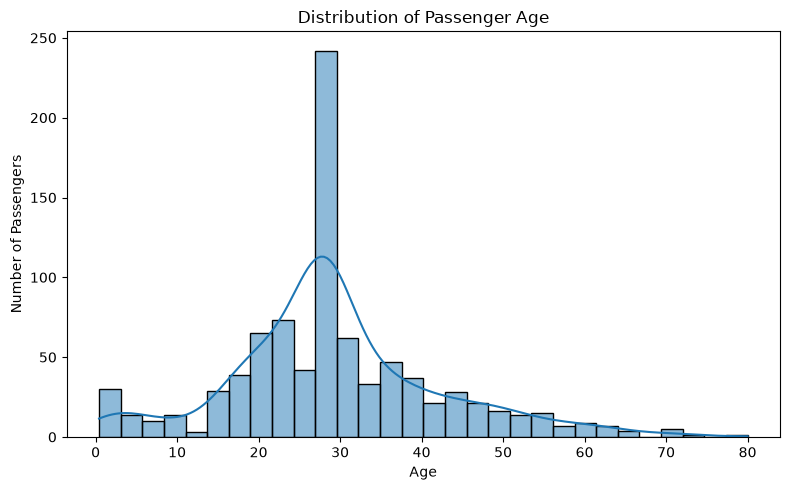

In [11]:
# ============================================
# Step 12: Age Histogram
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["age"],
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()

plt.show()

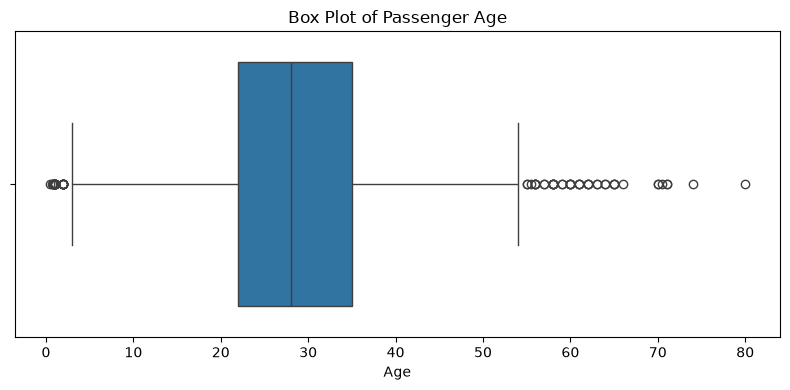

In [12]:
# ============================================
# Step 13: Age Box Plot
# ============================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=clean_df["age"]
)

plt.title("Box Plot of Passenger Age")
plt.xlabel("Age")

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# Step 14: Age IQR Outlier Detection
# ============================================

age_q1 = clean_df["age"].quantile(0.25)
age_q3 = clean_df["age"].quantile(0.75)

age_iqr = age_q3 - age_q1

age_lower_bound = age_q1 - 1.5 * age_iqr
age_upper_bound = age_q3 + 1.5 * age_iqr

age_outliers = clean_df[
    (clean_df["age"] < age_lower_bound) |
    (clean_df["age"] > age_upper_bound)
]

print("Age IQR Analysis")
print("=" * 60)
print(f"Q1:              {age_q1:.2f}")
print(f"Q3:              {age_q3:.2f}")
print(f"IQR:             {age_iqr:.2f}")
print(f"Lower Bound:     {age_lower_bound:.2f}")
print(f"Upper Bound:     {age_upper_bound:.2f}")
print(f"Number of Outliers: {len(age_outliers)}")

Age IQR Analysis
Q1:              22.00
Q3:              35.00
IQR:             13.00
Lower Bound:     2.50
Upper Bound:     54.50
Number of Outliers: 65


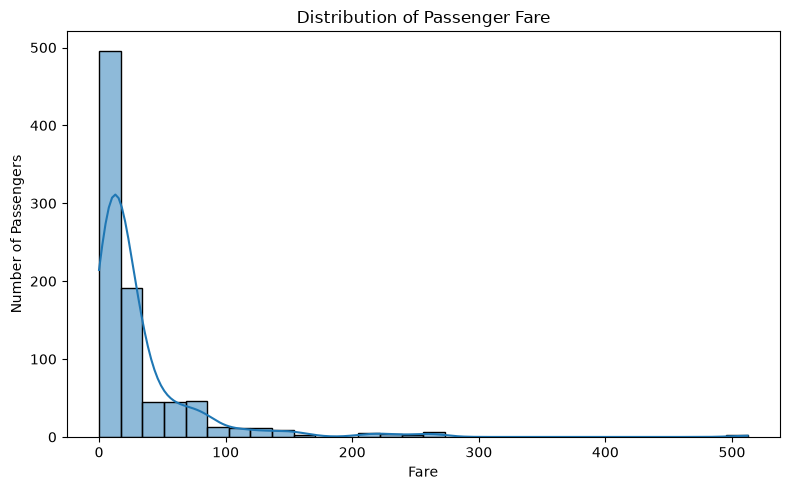

In [14]:
# ============================================
# Step 15: Fare Histogram
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["fare"],
    bins=30,
    kde=True
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()

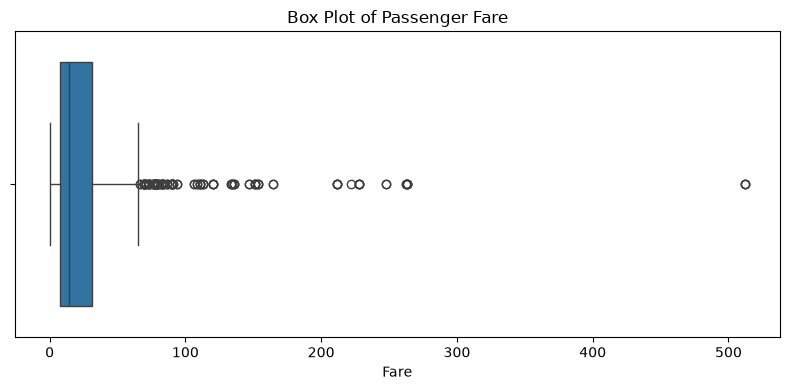

In [15]:
# ============================================
# Step 16: Fare Box Plot
# ============================================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=clean_df["fare"]
)

plt.title("Box Plot of Passenger Fare")
plt.xlabel("Fare")

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# Step 17: Fare IQR Outlier Detection
# ============================================

fare_q1 = clean_df["fare"].quantile(0.25)
fare_q3 = clean_df["fare"].quantile(0.75)

fare_iqr = fare_q3 - fare_q1

fare_lower_bound = fare_q1 - 1.5 * fare_iqr
fare_upper_bound = fare_q3 + 1.5 * fare_iqr

fare_outliers = clean_df[
    (clean_df["fare"] < fare_lower_bound) |
    (clean_df["fare"] > fare_upper_bound)
]

print("Fare IQR Analysis")
print("=" * 60)
print(f"Q1:                 {fare_q1:.2f}")
print(f"Q3:                 {fare_q3:.2f}")
print(f"IQR:                {fare_iqr:.2f}")
print(f"Lower Bound:        {fare_lower_bound:.2f}")
print(f"Upper Bound:        {fare_upper_bound:.2f}")
print(f"Number of Outliers: {len(fare_outliers)}")

Fare IQR Analysis
Q1:                 7.90
Q3:                 31.00
IQR:                23.10
Lower Bound:        -26.76
Upper Bound:        65.66
Number of Outliers: 114


In [17]:
# ============================================
# Step 18: Fare Mean, Median and Mode
# ============================================

fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()

print("Fare Statistics")
print("=" * 60)
print(f"Mean:   {fare_mean:.4f}")
print(f"Median: {fare_median:.4f}")
print(f"Mode:   {fare_mode.iloc[0]:.4f}")

Fare Statistics
Mean:   32.0967
Median: 14.4542
Mode:   8.0500


In [18]:
# ============================================
# Step 19: Fare Skewness
# ============================================

fare_skewness = clean_df["fare"].skew()

print("Fare Skewness")
print("=" * 60)
print(f"Skewness: {fare_skewness:.4f}")

Fare Skewness
Skewness: 4.8014


## Univariate Analysis Interpretation

### Age

The age histogram shows the distribution of passenger ages, while the box plot highlights the central range and potential extreme observations. The IQR method identifies the observations outside the lower and upper IQR boundaries as statistical outliers. These observations are reported but are not removed because the assignment requires outlier identification rather than automatic deletion.

### Fare

The fare histogram shows that most passengers paid relatively low fares, while a smaller number of passengers paid substantially higher fares. The box plot also shows several high-fare observations beyond the upper IQR boundary.

The fare distribution is **right-skewed** because the mean is greater than the median, and the median is greater than the mode. The positive skewness value provides additional numerical support for this conclusion. The long right tail is consistent with the presence of high-fare outliers.

In [19]:
# ============================================
# Step 18: Fare Mean, Median and Mode
# ============================================

fare_mean = clean_df["fare"].mean()
fare_median = clean_df["fare"].median()
fare_mode = clean_df["fare"].mode()

print("Fare Statistics")
print("=" * 60)
print(f"Mean:   {fare_mean:.4f}")
print(f"Median: {fare_median:.4f}")
print(f"Mode:   {fare_mode.iloc[0]:.4f}")

Fare Statistics
Mean:   32.0967
Median: 14.4542
Mode:   8.0500


In [20]:
# ============================================
# Step 19: Fare Skewness
# ============================================

fare_skewness = clean_df["fare"].skew()

print("Fare Skewness")
print("=" * 60)
print(f"Skewness: {fare_skewness:.4f}")

Fare Skewness
Skewness: 4.8014


## Univariate Analysis Interpretation

### Age

The age histogram shows the distribution of passenger ages, while the box plot highlights the central range and potential extreme observations. Using the IQR rule, the lower boundary is 2.50 and the upper boundary is 54.50, resulting in 65 statistical outliers. These observations are reported but are not removed because the assignment requires outlier identification rather than automatic deletion.

### Fare

The fare histogram shows that most passengers paid relatively low fares, while a smaller number of passengers paid substantially higher fares. The box plot confirms the presence of high-fare observations beyond the upper IQR boundary of 65.66. Using the IQR method, 114 fare observations are identified as statistical outliers.

The fare distribution is strongly right-skewed. The mean fare is 32.0967, the median is 14.4542, and the mode is 8.0500, giving the ordering Mean > Median > Mode. The skewness value of 4.8014 is strongly positive, providing additional evidence that the distribution has a long right tail caused by relatively high-fare observations.

In [21]:
# ============================================
# Step 21: Survival Rate by Sex
# ============================================

male_passengers = clean_df[clean_df["sex"] == "male"]
female_passengers = clean_df[clean_df["sex"] == "female"]

male_survival_rate = male_passengers["survived"].mean()
female_survival_rate = female_passengers["survived"].mean()

print("Survival Rate by Sex")
print("=" * 60)
print(f"Male:   {male_survival_rate:.4f} ({male_survival_rate * 100:.2f}%)")
print(f"Female: {female_survival_rate:.4f} ({female_survival_rate * 100:.2f}%)")

Survival Rate by Sex
Male:   0.1889 (18.89%)
Female: 0.7404 (74.04%)


In [22]:
# ============================================
# Step 22: Survival Rate by Passenger Class
# ============================================

first_class = clean_df[clean_df["pclass"] == 1]
second_class = clean_df[clean_df["pclass"] == 2]
third_class = clean_df[clean_df["pclass"] == 3]

first_survival_rate = first_class["survived"].mean()
second_survival_rate = second_class["survived"].mean()
third_survival_rate = third_class["survived"].mean()

print("Survival Rate by Passenger Class")
print("=" * 60)
print(f"1st Class: {first_survival_rate:.4f} ({first_survival_rate * 100:.2f}%)")
print(f"2nd Class: {second_survival_rate:.4f} ({second_survival_rate * 100:.2f}%)")
print(f"3rd Class: {third_survival_rate:.4f} ({third_survival_rate * 100:.2f}%)")

Survival Rate by Passenger Class
1st Class: 0.6262 (62.62%)
2nd Class: 0.4728 (47.28%)
3rd Class: 0.2424 (24.24%)


In [23]:
# ============================================
# Step 23: Survival Rate by Sex and Class
# ============================================

female_first = clean_df[
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 1)
]

female_second = clean_df[
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 2)
]

female_third = clean_df[
    (clean_df["sex"] == "female") &
    (clean_df["pclass"] == 3)
]

male_first = clean_df[
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 1)
]

male_second = clean_df[
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 2)
]

male_third = clean_df[
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 3)
]

print("Survival Rate by Sex and Passenger Class")
print("=" * 60)

print(f"Female, 1st Class: {female_first['survived'].mean():.4f}")
print(f"Female, 2nd Class: {female_second['survived'].mean():.4f}")
print(f"Female, 3rd Class: {female_third['survived'].mean():.4f}")

print(f"Male, 1st Class:   {male_first['survived'].mean():.4f}")
print(f"Male, 2nd Class:   {male_second['survived'].mean():.4f}")
print(f"Male, 3rd Class:   {male_third['survived'].mean():.4f}")

Survival Rate by Sex and Passenger Class
Female, 1st Class: 0.9674
Female, 2nd Class: 0.9211
Female, 3rd Class: 0.5000
Male, 1st Class:   0.3689
Male, 2nd Class:   0.1574
Male, 3rd Class:   0.1354


In [24]:
# ============================================
# Step 24: Bivariate Survival Summary
# ============================================

survival_by_sex = (
    clean_df
    .groupby("sex", observed=True)["survived"]
    .mean()
    .reset_index()
)

survival_by_class = (
    clean_df
    .groupby("pclass", observed=True)["survived"]
    .mean()
    .reset_index()
)

survival_by_sex_class = (
    clean_df
    .groupby(["sex", "pclass"], observed=True)["survived"]
    .mean()
    .reset_index()
)

print("Survival Rate by Sex")
display(survival_by_sex)

print("\nSurvival Rate by Passenger Class")
display(survival_by_class)

print("\nSurvival Rate by Sex and Passenger Class")
display(survival_by_sex_class)

Survival Rate by Sex


,sex,survived
0,female,0.740385
1,male,0.188908



Survival Rate by Passenger Class


,pclass,survived
0,1,0.626168
1,2,0.472826
2,3,0.242363



Survival Rate by Sex and Passenger Class


,sex,pclass,survived
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


### Bivariate Analysis Interpretation

Survival varied substantially by both sex and passenger class. Female passengers had much higher survival rates than male passengers across all three classes. Among females, survival was highest in 1st class (96.74%) and 2nd class (92.11%), while it dropped to 50.00% in 3rd class.

Male survival was considerably lower, with rates of 36.89% in 1st class, 15.74% in 2nd class, and 13.54% in 3rd class. Overall, the results suggest that sex was a particularly strong predictor of survival, while passenger class also contributed significantly to survival differences.

In [25]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[correlation_columns].corr()

print("Correlation Matrix")
print("=" * 60)

display(correlation_matrix.round(3))

Correlation Matrix


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


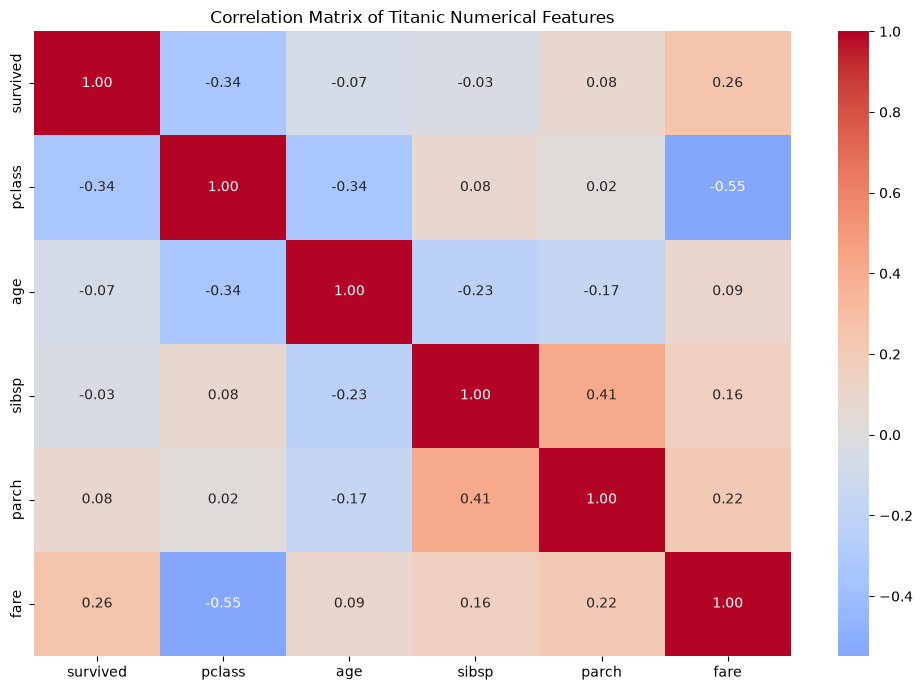

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Titanic Numerical Features")
plt.tight_layout()
plt.show()

### Correlation Analysis Interpretation

The correlation matrix was calculated using only `survived`, `pclass`, `age`, `sibsp`, `parch`, and `fare`, as required. The two strongest absolute off-diagonal correlations are between `pclass` and `fare` (-0.55) and between `sibsp` and `parch` (0.41).

The negative correlation of -0.55 between `pclass` and `fare` indicates that passengers in higher classes generally paid higher fares, while passengers in lower classes generally paid lower fares. The positive correlation of 0.41 between `sibsp` and `parch` indicates a moderate relationship between the number of siblings/spouses and parents/children traveling with a passenger.

There is also a moderate negative correlation between `survived` and `pclass` (-0.34), suggesting that survival was generally higher among passengers in higher classes.

## Multivariate Analysis

Multivariate analysis examines relationships among multiple variables simultaneously. The following visualizations explore how combinations of demographic, socioeconomic, and survival variables are related in the Titanic dataset.

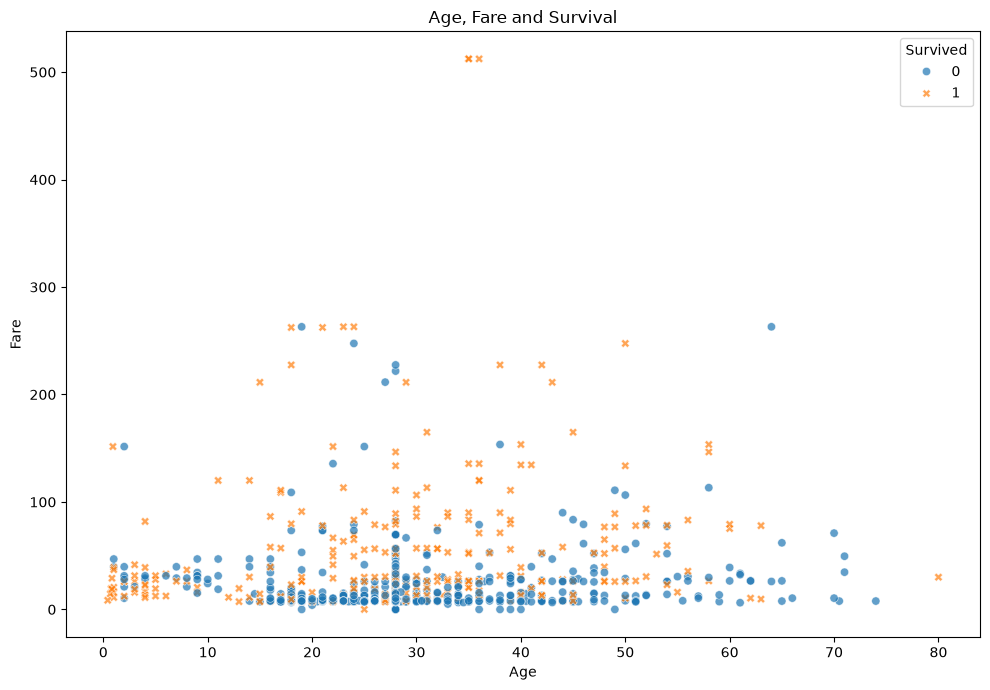

In [27]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived",
    style="survived",
    alpha=0.7
)

plt.title("Age, Fare and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(title="Survived")
plt.tight_layout()
plt.show()

### Chart 1: Age, Fare and Survival

The scatter plot shows the relationship between age, fare, and survival status. Most passengers paid relatively low fares, while a smaller number of passengers paid much higher fares, producing a wide spread in the fare variable. The plot also shows that survivors are present across different age groups and fare levels, although higher-fare passengers appear more frequently among survivors.

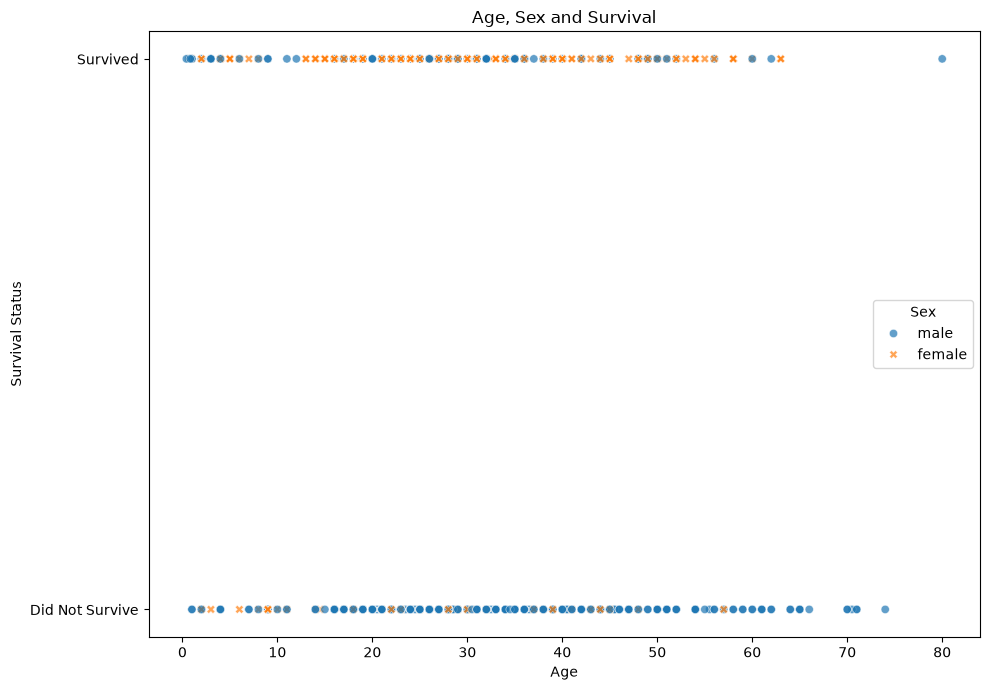

In [28]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="survived",
    hue="sex",
    style="sex",
    alpha=0.7
)

plt.title("Age, Sex and Survival")
plt.xlabel("Age")
plt.ylabel("Survival Status")
plt.yticks([0, 1], ["Did Not Survive", "Survived"])
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

### Chart 2: Age, Sex and Survival

The plot shows the distribution of passenger age by survival status, with sex represented using different colors and marker styles. Female passengers appear more frequently among the survivors, while male passengers make up a larger proportion of those who did not survive. Although survival occurs across a wide range of ages for both sexes, the plot suggests that sex had a stronger visible relationship with survival than age alone.

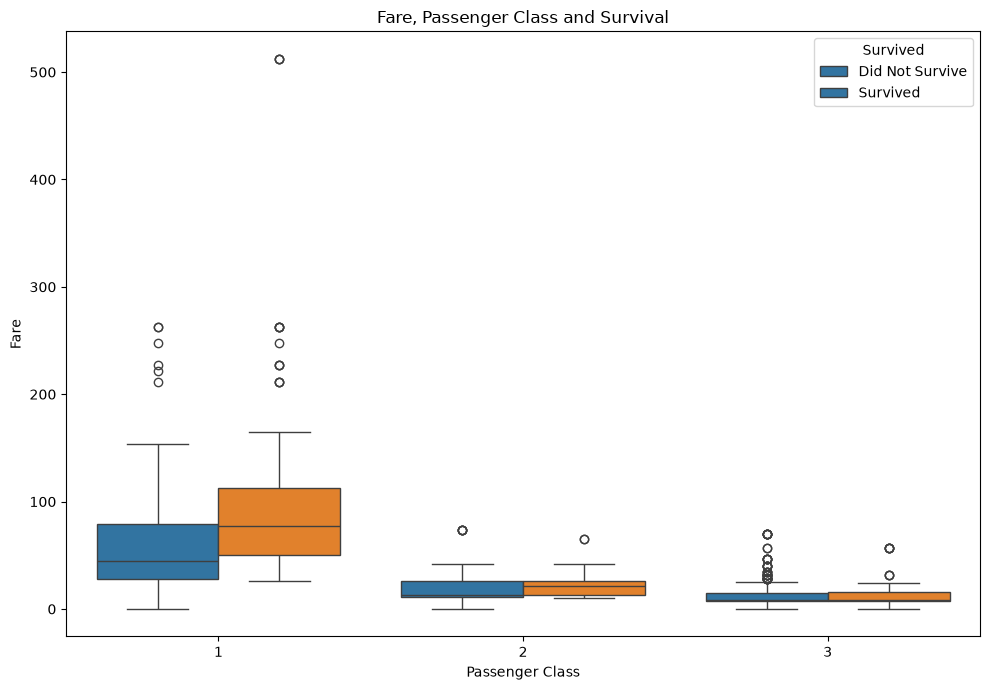

In [29]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=clean_df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare, Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Survived", labels=["Did Not Survive", "Survived"])
plt.tight_layout()
plt.show()

### Chart 3: Fare, Passenger Class and Survival

The box plot shows that fare distributions vary substantially across passenger classes, with 1st-class passengers generally paying much higher fares than 2nd- and 3rd-class passengers. Within 1st class, survivors tend to have higher fares than passengers who did not survive, while the difference is smaller in 2nd and 3rd class. The plot also contains several high-fare outliers, particularly in 1st class, which is consistent with the strong right-skewness observed in the earlier fare analysis.

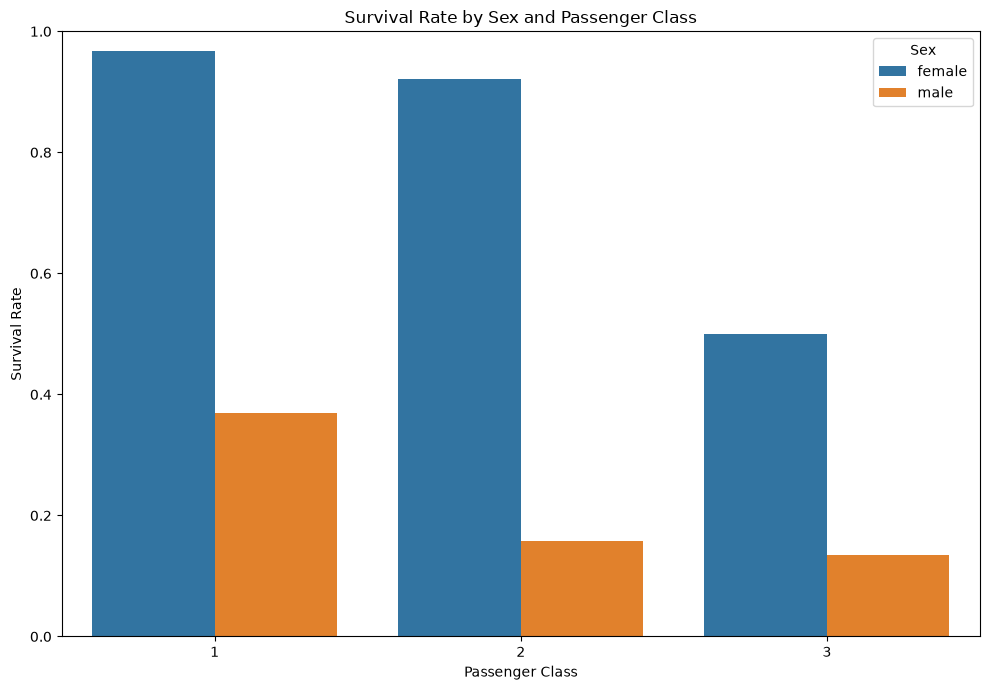

In [30]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.legend(title="Sex")
plt.tight_layout()
plt.show()

### Chart 4: Survival Rate by Sex and Passenger Class

The bar chart shows that female passengers had substantially higher survival rates than male passengers across all three passenger classes. Female survival was highest in 1st class at 96.74%, followed by 2nd class at 92.11%, and 3rd class at 50.00%. Male survival rates were much lower, at 36.89% in 1st class, 15.74% in 2nd class, and 13.54% in 3rd class. Overall, the combination of sex and passenger class shows a strong relationship with survival.

## Exploratory Standardization

Standardization transforms numerical variables so that they have a mean close to 0 and a standard deviation close to 1. Here, `age` and `fare` are standardized using the full cleaned dataset for exploratory analysis only. This transformation is separate from the modeling preprocessing pipeline to avoid data leakage during model training.

In [31]:
scaler = StandardScaler()

standardized_df = clean_df.copy()

standardized_df[["age_standardized", "fare_standardized"]] = scaler.fit_transform(
    standardized_df[["age", "fare"]]
)

print("Before Standardization")
print("=" * 60)
print(
    clean_df[["age", "fare"]].agg(["mean", "std"]).round(4)
)

print("\nAfter Standardization")
print("=" * 60)
print(
    standardized_df[["age_standardized", "fare_standardized"]]
    .agg(["mean", "std"])
    .round(4)
)

Before Standardization
          age     fare
mean  29.3152  32.0967
std   12.9849  49.6975

After Standardization
      age_standardized  fare_standardized
mean            0.0000             0.0000
std             1.0006             1.0006


### Exploratory Standardization Interpretation

The `age` and `fare` variables were standardized using `StandardScaler` on the full cleaned dataset for exploratory analysis. Before standardization, age had a mean of 29.3152 and a standard deviation of 12.9849, while fare had a mean of 32.0967 and a standard deviation of 49.6975.

After standardization, both variables had a mean of approximately 0 and a standard deviation of approximately 1. This confirms that the standardization was performed correctly. This exploratory transformation is not used as the modeling preprocessing step; the modeling pipeline will fit preprocessing only on the training data to prevent data leakage.

## Modeling

The modeling task is to predict passenger survival using demographic, socioeconomic, and travel-related features. The target variable is `survived`.

Features include passenger class, sex, age, number of siblings/spouses, number of parents/children, fare, and embarkation port. Columns that directly reveal the target or duplicate existing information are excluded to avoid target leakage and unnecessary redundancy.

In [32]:
from sklearn.model_selection import train_test_split

target_column = "survived"

feature_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = clean_df[feature_columns].copy()
y = clean_df[target_column].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True).round(4))

Feature shape: (889, 7)
Target shape: (889,)

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target proportions:
survived
0    0.6175
1    0.3825
Name: proportion, dtype: float64


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (711, 7)
Testing set: (178, 7)

Training target distribution:
survived
0    0.6174
1    0.3826
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [35]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked']


In [36]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [37]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [39]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Training data shape after preprocessing:", X_train_processed.shape)
print("Testing data shape after preprocessing:", X_test_processed.shape)

Preprocessing completed.
Training data shape after preprocessing: (711, 10)
Testing data shape after preprocessing: (178, 10)


In [40]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 10

Processed feature names:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S']


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Classification models imported successfully.")

Classification models imported successfully.


In [42]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

print("Three classification pipelines created successfully.")

Three classification pipelines created successfully.


In [43]:
print("Training Logistic Regression...")
logistic_pipeline.fit(X_train, y_train)

print("Training Decision Tree...")
decision_tree_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_pipeline.fit(X_train, y_train)

print("\nAll three models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All three models trained successfully.


In [44]:
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_tree = decision_tree_pipeline.predict(X_test)
y_pred_forest = random_forest_pipeline.predict(X_test)

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_forest = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

print("\nPrediction counts:")
print("Logistic Regression:", np.bincount(y_pred_logistic))
print("Decision Tree:", np.bincount(y_pred_tree))
print("Random Forest:", np.bincount(y_pred_forest))

Predictions generated successfully.

Prediction counts:
Logistic Regression: [118  60]
Decision Tree: [128  50]
Random Forest: [114  64]


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [46]:
def evaluate_classifier(name, y_true, y_pred, y_prob):
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    
    return results

In [47]:
results = []

results.append(
    evaluate_classifier(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        y_prob_logistic
    )
)

results.append(
    evaluate_classifier(
        "Decision Tree",
        y_test,
        y_pred_tree,
        y_prob_tree
    )
)

results.append(
    evaluate_classifier(
        "Random Forest",
        y_test,
        y_pred_forest,
        y_prob_forest
    )
)

classification_results = pd.DataFrame(results)

print("Classification Model Comparison")
display(
    classification_results.round(4)
)

Classification Model Comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.809,0.7656,0.7206,0.7424,0.8196


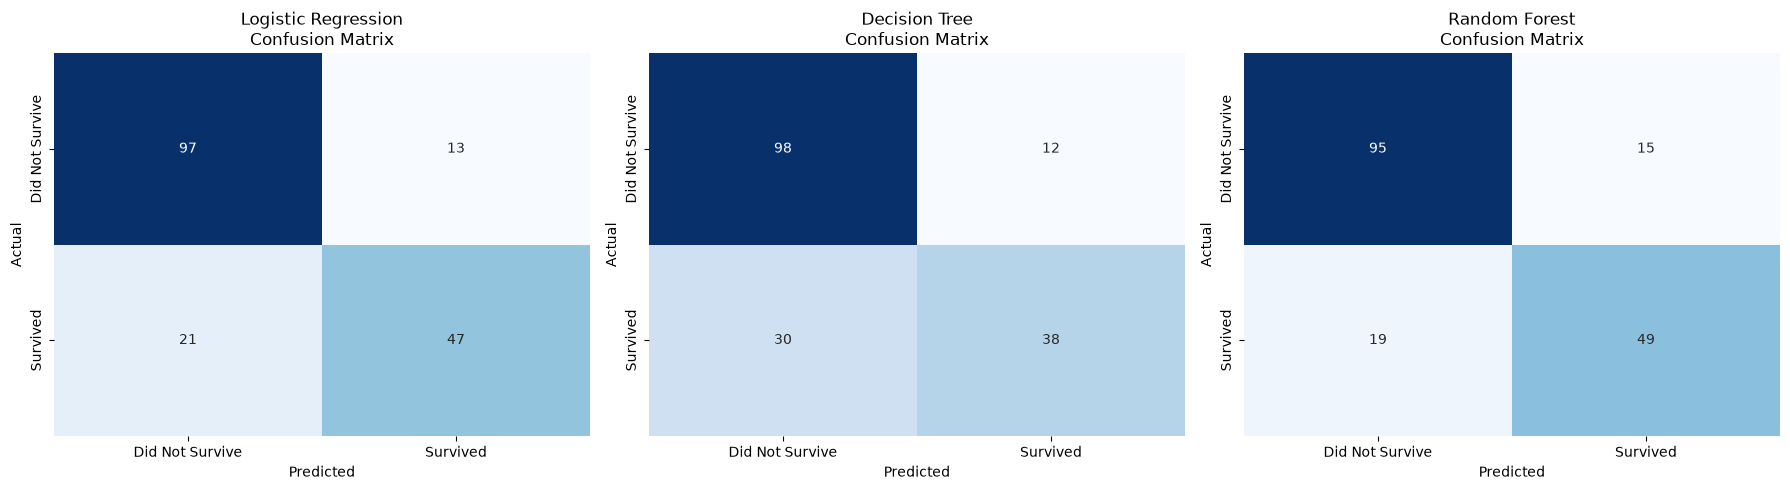

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_predictions = [
    ("Logistic Regression", y_pred_logistic),
    ("Decision Tree", y_pred_tree),
    ("Random Forest", y_pred_forest)
]

for ax, (name, y_pred) in zip(axes, models_predictions):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Did Not Survive", "Survived"])
    ax.set_yticklabels(["Did Not Survive", "Survived"])

plt.tight_layout()
plt.show()

In [49]:
print("=" * 70)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Did Not Survive", "Survived"]
))

print("=" * 70)
print("DECISION TREE - CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["Did Not Survive", "Survived"]
))

print("=" * 70)
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    y_test,
    y_pred_forest,
    target_names=["Did Not Survive", "Survived"]
))

LOGISTIC REGRESSION - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.78      0.69      0.73        68

       accuracy                           0.81       178
      macro avg       0.80      0.79      0.79       178
   weighted avg       0.81      0.81      0.81       178

DECISION TREE - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Did Not Survive       0.77      0.89      0.82       110
       Survived       0.76      0.56      0.64        68

       accuracy                           0.76       178
      macro avg       0.76      0.72      0.73       178
   weighted avg       0.76      0.76      0.75       178

RANDOM FOREST - CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.85       110
       Survived       0.77      0.72      0.74        68

       accuracy  

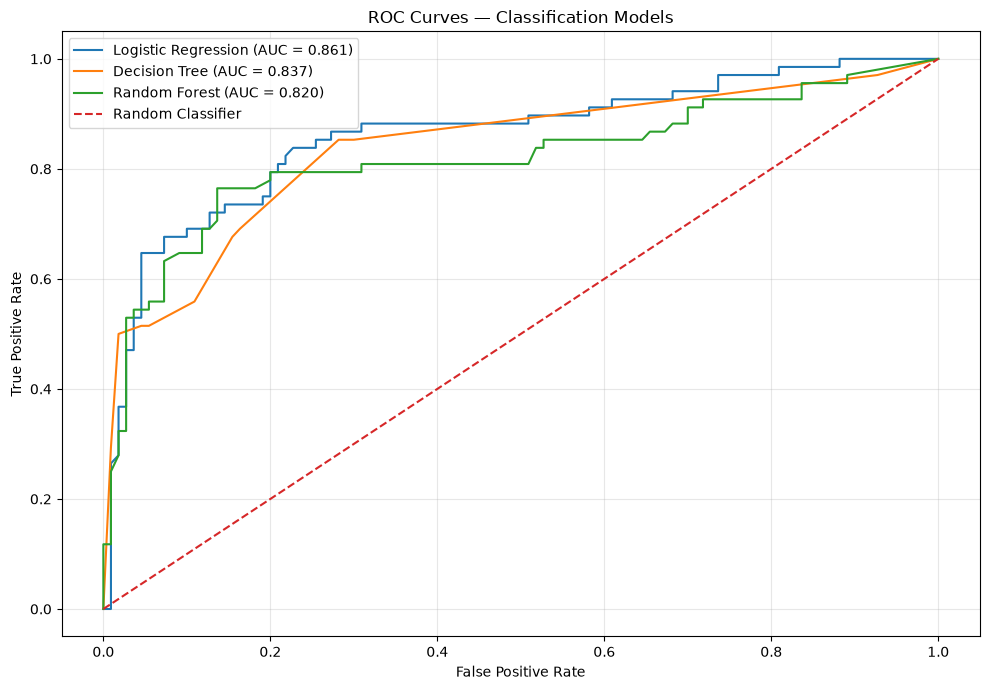

In [50]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

fpr_forest, tpr_forest, _ = roc_curve(
    y_test,
    y_prob_forest
)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_tree):.3f})"
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_forest):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curves — Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

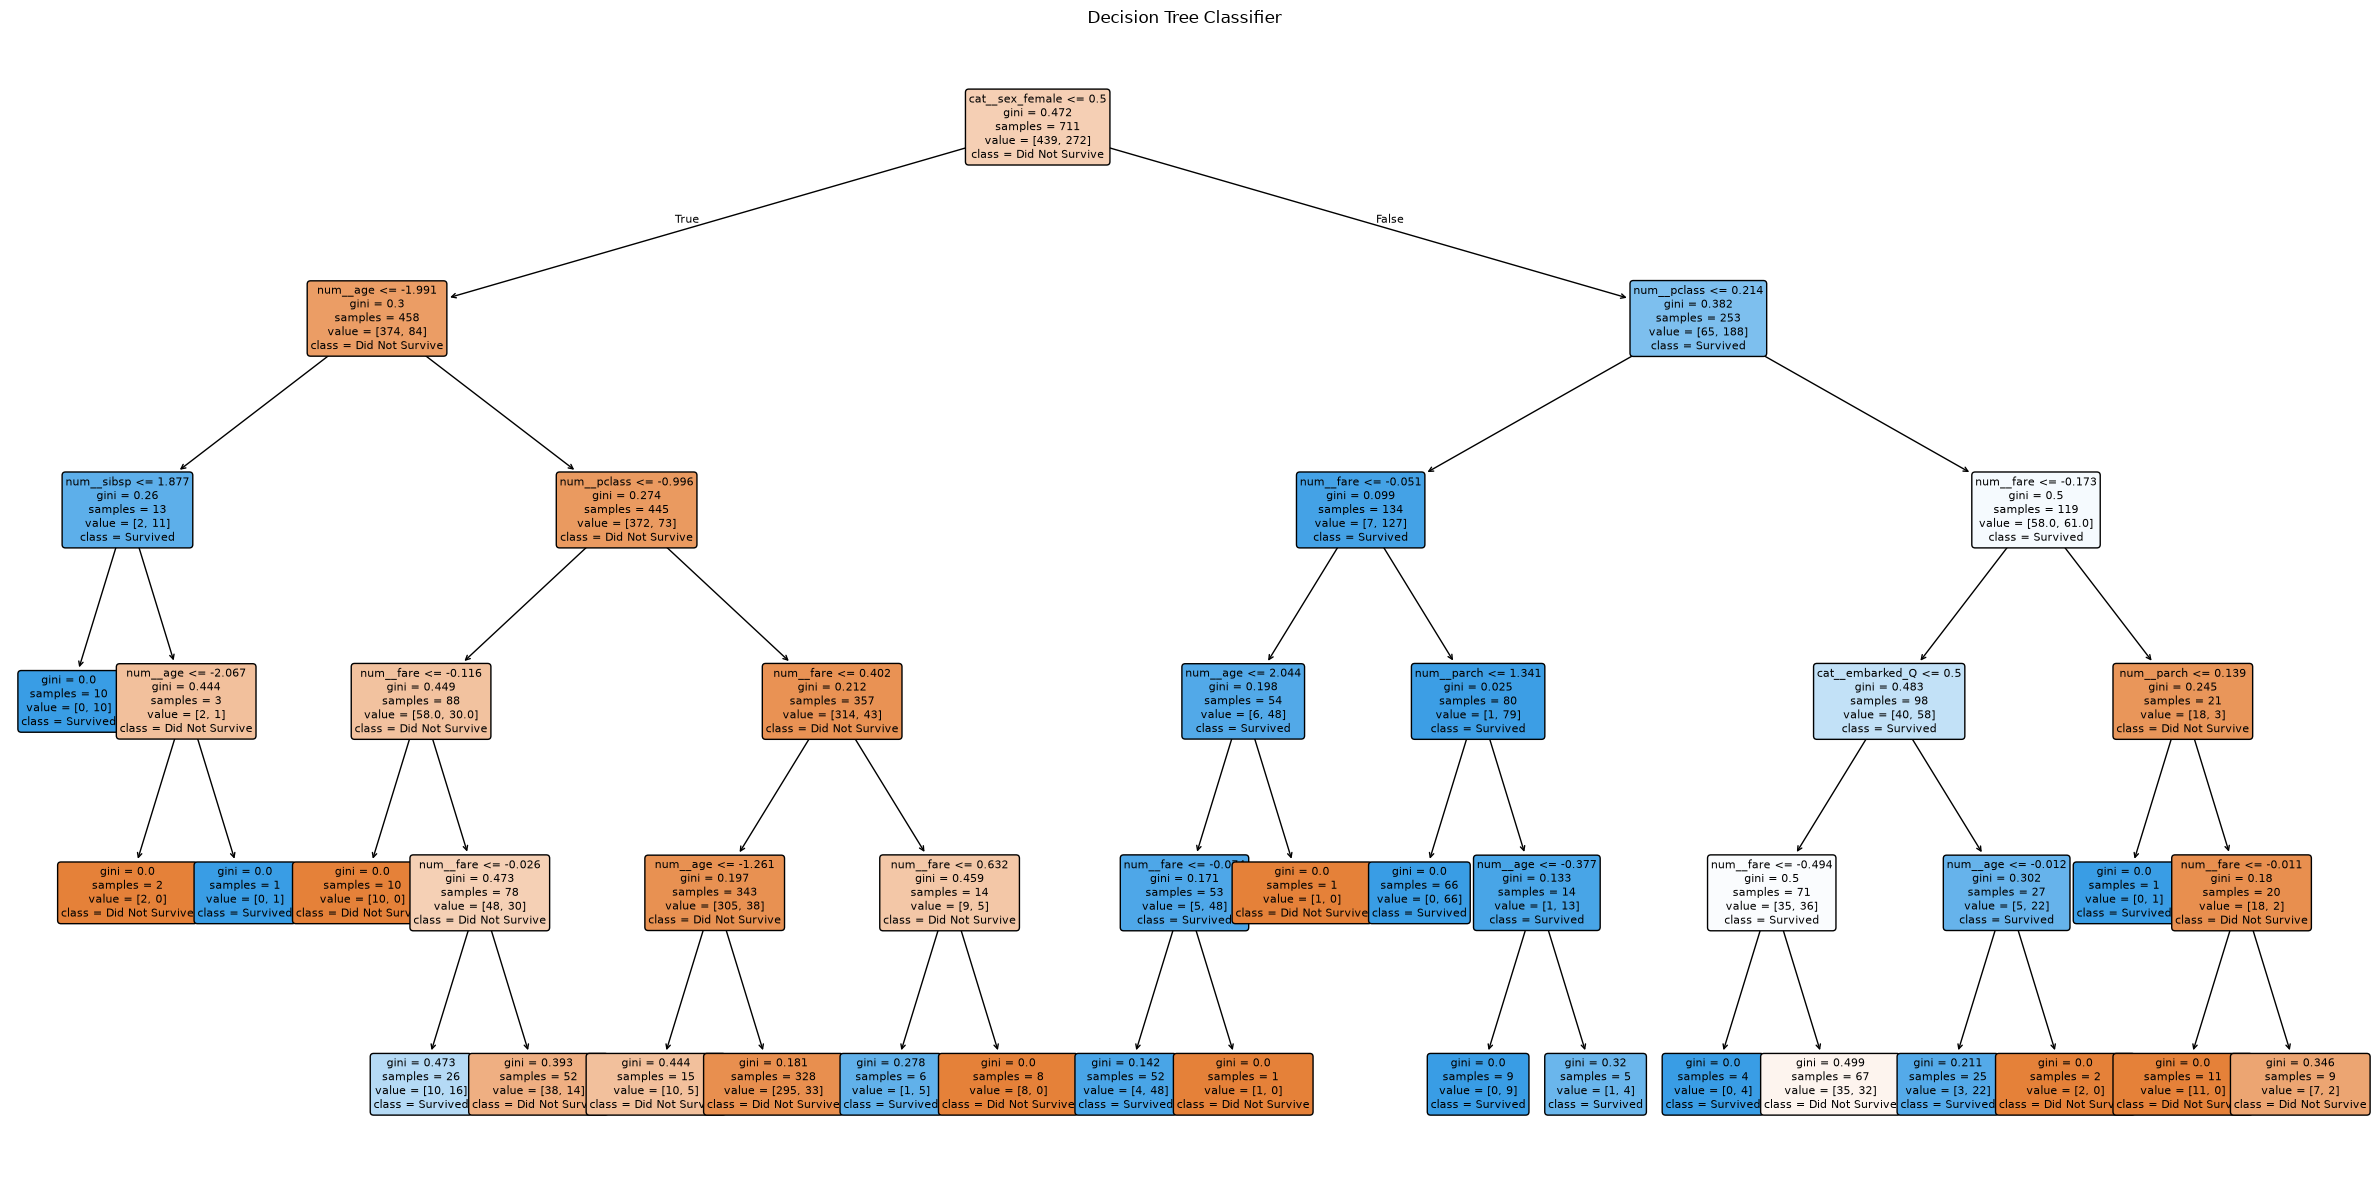

In [51]:
from sklearn.tree import plot_tree

tree_model = decision_tree_pipeline.named_steps["classifier"]
tree_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

tree_feature_names = tree_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.tight_layout()
plt.show()

### Classification Evaluation Interpretation

The three baseline classifiers were evaluated using confusion matrices, accuracy, precision, recall, F1-score, and ROC-AUC. Logistic Regression and Random Forest both achieved 80.90% accuracy, while Decision Tree achieved 76.40%.

Logistic Regression achieved the highest ROC-AUC of 0.8610 and the highest precision of 0.7833. Random Forest achieved the highest recall of 0.7206 and the highest F1-score of 0.7424, indicating that it identified a larger proportion of actual survivors while maintaining a good balance between precision and recall.

The confusion matrices show that Random Forest correctly identified 49 of the 68 surviving passengers and missed 19 survivors. Logistic Regression correctly identified 47 survivors and missed 21, while Decision Tree correctly identified only 38 and missed 30.

Overall, Logistic Regression and Random Forest are stronger baseline models than the Decision Tree. However, model selection will be revisited after addressing class imbalance and tuning the Random Forest.

## Class Imbalance Analysis

The Titanic target contains 61.75% non-survivors and 38.25% survivors. Although the imbalance is moderate rather than extreme, both class weighting and SMOTE are evaluated to determine whether improving representation of the minority class improves survival prediction.

The baseline models are compared against models using `class_weight="balanced"` and SMOTE. Precision, recall, and F1-score are emphasized because accuracy alone may hide differences in minority-class performance.

In [52]:
balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Balanced classification pipelines created successfully.")

Balanced classification pipelines created successfully.


In [53]:
print("Training balanced Logistic Regression...")
balanced_logistic_pipeline.fit(X_train, y_train)

print("Training balanced Decision Tree...")
balanced_tree_pipeline.fit(X_train, y_train)

print("Training balanced Random Forest...")
balanced_forest_pipeline.fit(X_train, y_train)

print("\nAll balanced models trained successfully.")

Training balanced Logistic Regression...
Training balanced Decision Tree...
Training balanced Random Forest...

All balanced models trained successfully.


In [54]:
balanced_pred_logistic = balanced_logistic_pipeline.predict(X_test)
balanced_pred_tree = balanced_tree_pipeline.predict(X_test)
balanced_pred_forest = balanced_forest_pipeline.predict(X_test)

balanced_prob_logistic = balanced_logistic_pipeline.predict_proba(X_test)[:, 1]
balanced_prob_tree = balanced_tree_pipeline.predict_proba(X_test)[:, 1]
balanced_prob_forest = balanced_forest_pipeline.predict_proba(X_test)[:, 1]

print("Balanced model predictions generated successfully.")

Balanced model predictions generated successfully.


In [55]:
balanced_results = []

balanced_results.append(
    evaluate_classifier(
        "Logistic Regression - Balanced",
        y_test,
        balanced_pred_logistic,
        balanced_prob_logistic
    )
)

balanced_results.append(
    evaluate_classifier(
        "Decision Tree - Balanced",
        y_test,
        balanced_pred_tree,
        balanced_prob_tree
    )
)

balanced_results.append(
    evaluate_classifier(
        "Random Forest - Balanced",
        y_test,
        balanced_pred_forest,
        balanced_prob_forest
    )
)

balanced_classification_results = pd.DataFrame(balanced_results)

print("Balanced Classification Results")
display(
    balanced_classification_results.round(4)
)

Balanced Classification Results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression - Balanced,0.7921,0.7183,0.7500,0.7338,0.8612
1,Decision Tree - Balanced,0.7753,0.7188,0.6765,0.6970,0.8255
2,Random Forest - Balanced,0.8146,0.7536,0.7647,0.7591,0.8204


### Class Weight Balancing Interpretation

The `class_weight="balanced"` experiment was performed to give greater importance to the minority survival class during model training. Compared with the baseline models, class weighting generally increased recall for the surviving class, although precision decreased in several cases.

For Logistic Regression, recall increased from 0.6912 to 0.7500, while F1 remained almost unchanged. Decision Tree recall increased from 0.5588 to 0.6765 and its F1-score improved from 0.6441 to 0.6970.

Random Forest showed the strongest overall improvement. Its recall increased from 0.7206 to 0.7647, F1-score increased from 0.7424 to 0.7591, and accuracy increased from 0.8090 to 0.8146. Therefore, class weighting was particularly effective for the Random Forest model.

In [56]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("SMOTE and imbalanced-learn pipeline imported successfully.")

SMOTE and imbalanced-learn pipeline imported successfully.


In [57]:
smote = SMOTE(
    random_state=42
)

smote_logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

smote_tree_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

smote_forest_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

print("SMOTE pipelines created successfully.")

SMOTE pipelines created successfully.


In [58]:
print("Training SMOTE Logistic Regression...")
smote_logistic_pipeline.fit(X_train, y_train)

print("Training SMOTE Decision Tree...")
smote_tree_pipeline.fit(X_train, y_train)

print("Training SMOTE Random Forest...")
smote_forest_pipeline.fit(X_train, y_train)

print("\nAll SMOTE models trained successfully.")

Training SMOTE Logistic Regression...
Training SMOTE Decision Tree...
Training SMOTE Random Forest...

All SMOTE models trained successfully.


In [59]:
smote_pred_logistic = smote_logistic_pipeline.predict(X_test)
smote_pred_tree = smote_tree_pipeline.predict(X_test)
smote_pred_forest = smote_forest_pipeline.predict(X_test)

smote_prob_logistic = smote_logistic_pipeline.predict_proba(X_test)[:, 1]
smote_prob_tree = smote_tree_pipeline.predict_proba(X_test)[:, 1]
smote_prob_forest = smote_forest_pipeline.predict_proba(X_test)[:, 1]

print("SMOTE predictions generated successfully.")

SMOTE predictions generated successfully.


In [60]:
smote_results = []

smote_results.append(
    evaluate_classifier(
        "Logistic Regression - SMOTE",
        y_test,
        smote_pred_logistic,
        smote_prob_logistic
    )
)

smote_results.append(
    evaluate_classifier(
        "Decision Tree - SMOTE",
        y_test,
        smote_pred_tree,
        smote_prob_tree
    )
)

smote_results.append(
    evaluate_classifier(
        "Random Forest - SMOTE",
        y_test,
        smote_pred_forest,
        smote_prob_forest
    )
)

smote_classification_results = pd.DataFrame(smote_results)

print("SMOTE Classification Results")
display(
    smote_classification_results.round(4)
)

SMOTE Classification Results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression - SMOTE,0.7978,0.7353,0.7353,0.7353,0.8667
1,Decision Tree - SMOTE,0.7697,0.6667,0.7941,0.7248,0.8287
2,Random Forest - SMOTE,0.8146,0.7612,0.7500,0.7556,0.8265


### Class Imbalance Comparison

The baseline, `class_weight="balanced"`, and SMOTE approaches were compared using precision, recall, and F1-score. Class weighting generally improved recall for the surviving class, while precision sometimes decreased because the models became more willing to predict passengers as survivors.

For Logistic Regression, SMOTE increased recall from 0.6912 to 0.7353, while class weighting produced the highest recall of 0.7500. For Decision Tree, SMOTE produced the highest recall of 0.7941, but its precision decreased to 0.6667.

Random Forest achieved the strongest overall balance with `class_weight="balanced"`, obtaining precision of 0.7536, recall of 0.7647, and F1-score of 0.7591. Therefore, the balanced Random Forest is currently the strongest configuration based on the combination of precision, recall, and F1-score.

In [61]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [62]:
rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                oob_score=True,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest tuning pipeline created successfully.")

Random Forest tuning pipeline created successfully.


In [63]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__max_features": ["sqrt", "log2"]
}

print("Parameter grid:")
print(param_grid)

Parameter grid:
{'classifier__n_estimators': [100, 200, 300], 'classifier__max_depth': [None, 5, 10, 15], 'classifier__max_features': ['sqrt', 'log2']}


In [64]:
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    refit=True,
    verbose=1
)

print("Starting Random Forest GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nGridSearchCV completed successfully.")

Starting Random Forest GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

GridSearchCV completed successfully.


In [65]:
print("Best Parameters:")
print("=" * 60)

for parameter, value in grid_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search.best_score_:.4f}")

Best Parameters:
classifier__max_depth: 15
classifier__max_features: sqrt
classifier__n_estimators: 200

Best Cross-Validation F1 Score:
0.7471


In [66]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps["classifier"]

print("Best Random Forest OOB Score:")
print(f"{best_rf_model.oob_score_:.4f}")

Best Random Forest OOB Score:
0.8073


### Random Forest Hyperparameter Tuning

GridSearchCV was used to tune the Random Forest over `n_estimators`, `max_depth`, and `max_features`. A total of 24 parameter combinations were evaluated using 5-fold cross-validation, resulting in 120 model fits.

The best configuration was `n_estimators=200`, `max_depth=15`, and `max_features='sqrt'`. This configuration achieved a best cross-validation F1-score of 0.7471. The fitted best Random Forest achieved an OOB score of 0.8073, providing an additional internal estimate of model performance.

In [67]:
tuned_rf_pred = best_rf_pipeline.predict(X_test)
tuned_rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_rf_results = evaluate_classifier(
    "Tuned Random Forest",
    y_test,
    tuned_rf_pred,
    tuned_rf_prob
)

print("Tuned Random Forest Test Results")
print("=" * 60)

for metric, value in tuned_rf_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.4f}")

Tuned Random Forest Test Results
Accuracy: 0.8146
Precision: 0.7869
Recall: 0.7059
F1: 0.7442
ROC-AUC: 0.8197


In [68]:
tuned_rf_cm = confusion_matrix(y_test, tuned_rf_pred)

print("Tuned Random Forest Confusion Matrix")
print("=" * 60)

display(
    pd.DataFrame(
        tuned_rf_cm,
        index=["Actual: Did Not Survive", "Actual: Survived"],
        columns=["Predicted: Did Not Survive", "Predicted: Survived"]
    )
)

Tuned Random Forest Confusion Matrix


,Predicted: Did Not Survive,Predicted: Survived
Actual: Did Not Survive,97,13
Actual: Survived,20,48


In [70]:
print("Tuned Random Forest Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        tuned_rf_pred,
        target_names=["Did Not Survive", "Survived"]
    )
)

Tuned Random Forest Classification Report
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.88      0.85       110
       Survived       0.79      0.71      0.74        68

       accuracy                           0.81       178
      macro avg       0.81      0.79      0.80       178
   weighted avg       0.81      0.81      0.81       178



### Tuned Random Forest Evaluation

The best Random Forest identified by GridSearchCV was evaluated on the untouched test dataset. The tuned model achieved approximately 81% accuracy, with 0.79 precision, 0.71 recall, and 0.74 F1-score for the surviving class.

Compared with the baseline Random Forest, the tuned model produced similar overall test performance. Therefore, hyperparameter tuning did not result in a major improvement in the selected test metrics, although the tuned model provides a systematically selected configuration based on 5-fold cross-validation.

In [71]:
tuned_rf_auc = roc_auc_score(
    y_test,
    tuned_rf_prob
)

print(f"Tuned Random Forest ROC-AUC: {tuned_rf_auc:.4f}")

Tuned Random Forest ROC-AUC: 0.8197


In [72]:
tuned_rf_cm = confusion_matrix(
    y_test,
    tuned_rf_pred
)

print("Tuned Random Forest Confusion Matrix")
print("=" * 60)

display(
    pd.DataFrame(
        tuned_rf_cm,
        index=["Actual: Did Not Survive", "Actual: Survived"],
        columns=["Predicted: Did Not Survive", "Predicted: Survived"]
    )
)

Tuned Random Forest Confusion Matrix


,Predicted: Did Not Survive,Predicted: Survived
Actual: Did Not Survive,97,13
Actual: Survived,20,48


## Multivariate Linear Regression

A multivariate linear regression model is used to predict passenger fare from multiple available passenger and travel-related features. The target variable is `fare`, and `fare` itself is excluded from the predictor variables to prevent target leakage.

Categorical variables are encoded using one-hot encoding, while numerical variables are scaled. The regression model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), R², and Adjusted R².

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Regression libraries imported successfully.")

Regression libraries imported successfully.


In [74]:
regression_features = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = clean_df[regression_features].copy()
y_reg = clean_df["fare"].copy()

print("Regression feature shape:", X_reg.shape)
print("Regression target shape:", y_reg.shape)

print("\nRegression features:")
print(regression_features)

print("\nRegression target:")
print("fare")

Regression feature shape: (889, 7)
Regression target shape: (889,)

Regression features:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Regression target:
fare


In [75]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training set:", X_reg_train.shape)
print("Regression testing set:", X_reg_test.shape)

Regression training set: (711, 7)
Regression testing set: (178, 7)


In [76]:
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            reg_numeric_transformer,
            reg_numeric_features
        ),
        (
            "cat",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)

print("Regression preprocessing pipeline created successfully.")

Regression preprocessing pipeline created successfully.


In [77]:
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully.")

Linear Regression pipeline created successfully.


In [78]:
print("Training multivariate linear regression...")

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("Regression model trained successfully.")

Training multivariate linear regression...
Regression model trained successfully.


In [79]:
y_reg_pred = regression_pipeline.predict(X_reg_test)

print("Fare predictions generated successfully.")

print("\nFirst 10 actual fares:")
print(y_reg_test.head(10).to_numpy())

print("\nFirst 10 predicted fares:")
print(np.round(y_reg_pred[:10], 2))

Fare predictions generated successfully.

First 10 actual fares:
[  7.8542 120.      11.2417  13.      79.65     6.975   13.       8.6625
 110.8833 106.425 ]

First 10 predicted fares:
[ -3.06  95.97  28.28  28.68  89.34  -1.13  29.22  -2.32 100.55  84.28]


In [80]:
mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

# Number of observations and predictors
n = len(y_reg_test)

regression_feature_count = (
    len(reg_numeric_features)
    + len(
        regression_pipeline
        .named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(reg_categorical_features)
    )
)

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - regression_feature_count - 1)
)

print("Multivariate Linear Regression Metrics")
print("=" * 60)
print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"R²:          {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"\nNumber of test observations (n): {n}")
print(f"Number of predictors (p):       {regression_feature_count}")

Multivariate Linear Regression Metrics
MAE:         21.0986
RMSE:        41.7021
R²:          0.3482
Adjusted R²: 0.3091

Number of test observations (n): 178
Number of predictors (p):       10


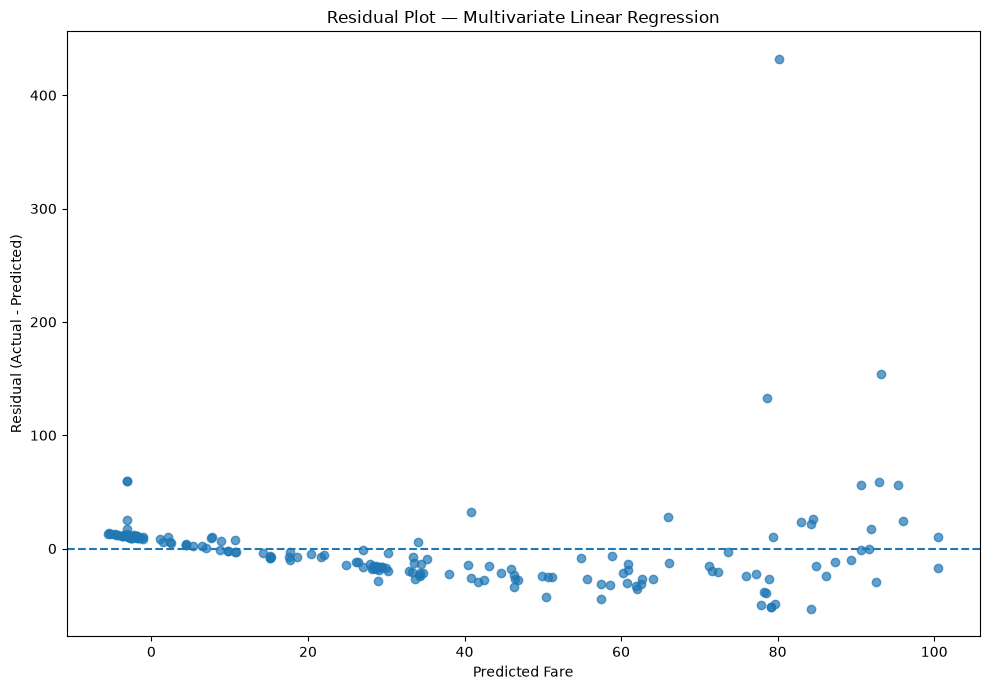

In [81]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(10, 7))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot — Multivariate Linear Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

### Regression Evaluation and Residual Analysis

The multivariate linear regression model achieved an MAE of 21.0986, RMSE of 41.7021, R² of 0.3482, and adjusted R² of 0.3091 on the test dataset. The R² value indicates that the model explains approximately 34.82% of the variation in passenger fare, while the lower adjusted R² accounts for the number of predictors used.

The residual plot shows that the spread of residuals increases as predicted fare increases, with several large residuals at higher predicted fare values. This indicates evidence of heteroscedasticity, meaning that the variance of the regression errors is not constant. This behavior is consistent with the strong right-skewness and high-fare outliers identified during the earlier exploratory analysis.

In [82]:
final_classification_results = pd.concat(
    [
        classification_results,
        balanced_classification_results,
        smote_classification_results,
        pd.DataFrame([tuned_rf_results])
    ],
    ignore_index=True
)

print("Final Classification Model Comparison")
display(
    final_classification_results.round(4)
)

Final Classification Model Comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196
3,Logistic Regression - Balanced,0.7921,0.7183,0.7500,0.7338,0.8612
4,Decision Tree - Balanced,0.7753,0.7188,0.6765,0.6970,0.8255
5,Random Forest - Balanced,0.8146,0.7536,0.7647,0.7591,0.8204
6,Logistic Regression - SMOTE,0.7978,0.7353,0.7353,0.7353,0.8667
7,Decision Tree - SMOTE,0.7697,0.6667,0.7941,0.7248,0.8287
8,Random Forest - SMOTE,0.8146,0.7612,0.7500,0.7556,0.8265
9,Tuned Random Forest,0.8146,0.7869,0.7059,0.7442,0.8197


In [83]:
final_regression_results = pd.DataFrame([
    {
        "Model": "Multivariate Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2
    }
])

print("Final Regression Model Comparison")
display(
    final_regression_results.round(4)
)

Final Regression Model Comparison


,Model,MAE,RMSE,R²,Adjusted R²
0,Multivariate Linear Regression,21.0986,41.7021,0.3482,0.3091


## Final Classifier Deployment Recommendation

The Balanced Random Forest is recommended as the final classifier because it achieved the highest overall accuracy of 81.46%, the highest recall of 76.47%, and the highest F1-score of 75.91% among the evaluated configurations. Its recall indicates that it identifies a larger proportion of actual survivors than the baseline Logistic Regression and Random Forest models. Logistic Regression achieved the highest ROC-AUC among the baseline models at 0.8610, and the SMOTE Logistic Regression achieved 0.8667, showing strong ranking/discrimination performance. However, considering the balance between accuracy, precision, recall, and F1-score, the Balanced Random Forest provides the most suitable overall classification performance for deployment.

In [84]:
from pathlib import Path
import joblib

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "best_titanic_classifier.joblib"

joblib.dump(
    balanced_forest_pipeline,
    model_path
)

print("Complete classification pipeline saved successfully.")
print("File:", model_path.resolve())

Complete classification pipeline saved successfully.
File: C:\zepto-data-ai-platform\analytics\models\best_titanic_classifier.joblib


In [85]:
loaded_pipeline = joblib.load(model_path)

print("Pipeline reloaded successfully.")
print(type(loaded_pipeline))

Pipeline reloaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [86]:
raw_passenger = pd.DataFrame({
    "pclass": [1],
    "sex": ["female"],
    "age": [30],
    "sibsp": [0],
    "parch": [0],
    "fare": [80.0],
    "embarked": ["C"]
})

prediction = loaded_pipeline.predict(raw_passenger)
probability = loaded_pipeline.predict_proba(raw_passenger)[0, 1]

print("Raw Passenger Input:")
display(raw_passenger)

print("Predicted Survival:", prediction[0])
print(f"Probability of Survival: {probability:.4f}")

Raw Passenger Input:


,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,30,0,0,80.0,C


Predicted Survival: 1
Probability of Survival: 1.0000
